# Support Vector Regression (SVR) — Google Colab

**Goal:** Predict a continuous target using **Support Vector Regression** — powerful for **non-linear** relationships.

| Example | Feature (X) | Target (y) | Dataset |
|---------|-------------|------------|---------|
| **Example 1** | Level | Salary | `../Datasets/Position_Salaries.csv` |
| **Example 2** | Speed_kmh | Braking_distance_m | `../Datasets/braking_distance.csv` |

| Phase | Topic | Cells |
|-------|-------|-------|
| Phase 0 | Setup | Install & Imports |
| — | Algorithm Guide | Definitions, equations, hyperparameters |
| Phase 1 | Data Pre-processing | Load → Cleaning → Encoding → Split → **Scaling** |
| Phase 2 | Algorithm | Train → Predict → Visualize → Evaluate |

> **Run:** Runtime → Run all (or Ctrl+F9)

---
# Algorithm Guide — Support Vector Regression (SVR)

## What is SVR?

**Support Vector Regression (SVR)** is a regression algorithm based on **Support Vector Machines (SVM)**.  
It finds a function that fits the data while keeping predictions inside an **ε-tube** (margin of tolerance).

## The Idea (Simple)

| Concept | Meaning |
|---------|--------|
| **Support Vectors** | The most important training points that define the model |
| **ε (epsilon)** | Errors smaller than ε are ignored — no penalty |
| **C** | Controls trade-off: large C = fit data closely, small C = smoother model |
| **Kernel** | Transforms features to capture non-linear patterns (e.g. `rbf`) |

## Equation (Student Version)

**Linear SVR:**

`y = w·x + b`  (with ε-insensitive loss)

**With kernel (non-linear):**

`y = Σ(αᵢ − αᵢ*) · K(xᵢ, x) + b`

Where `K(xᵢ, x)` is the kernel function (e.g. RBF: `exp(−γ||x − x'||²)`).

## Optimization Goal

Minimize:

` (1/2)||w||² + C · Σ(ξᵢ + ξᵢ*) `

Subject to predictions staying within **ε** of the true value.

## Key Hyperparameters

| Parameter | Role | Typical values |
|-----------|------|----------------|
| `kernel` | Shape of decision surface | `'rbf'`, `'linear'`, `'poly'` |
| `C` | Regularization strength | `1`, `10`, `100` |
| `epsilon` | Width of ε-tube | `0.01` – `0.2` |
| `gamma` | RBF kernel influence (`rbf` only) | `'scale'`, `'auto'`, or float |

## SVR vs Linear Regression

| | Linear Regression | SVR |
|---|-------------------|-----|
| Shape | Straight line / plane | Can be **curved** (with RBF kernel) |
| Scaling | Optional (1 feature) | **Required** |
| Outliers | Sensitive | More robust (ε-tube) |
| Interpretability | Easy (coefficients) | Harder (kernel-based) |

## What the Student Must Remember

1. **Always apply Feature Scaling** before SVR (`StandardScaler`).
2. Use **`kernel='rbf'`** when the relationship is non-linear.
3. **`C` too high** → overfitting; **`C` too low** → underfitting.
4. **`epsilon`** defines how much error you tolerate without penalty.
5. Evaluate with **MAE, RMSE, R²** — same as other regression models.

## Phase 0 — Cell 0: Install Libraries

Google Colab usually includes most libraries. This cell ensures required packages are available.

**What this cell does:** Installs scikit-learn, pandas, matplotlib, numpy, and seaborn quietly.

In [61]:
# Install into the same Python as this notebook kernel (avoids pip/kernel mismatch)
import sys
!{sys.executable} -m pip install -q scikit-learn pandas matplotlib numpy



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python3.11 -m pip install --upgrade pip


## Phase 0 — Cell 1: Import Libraries

Import libraries for data handling, preprocessing, modeling, and evaluation.

**What this cell does:** Loads numpy, pandas, matplotlib, seaborn, sklearn SVR, and scalers.

In [62]:
# --- Import libraries ---
import numpy as np              # Numerical operations and arrays
import pandas as pd             # Load and manipulate tabular data
import matplotlib.pyplot as plt # Create charts and plots

from sklearn.model_selection import train_test_split  # Split data into train/test
from sklearn.impute import SimpleImputer              # Fill missing values
from sklearn.preprocessing import StandardScaler      # Feature scaling (required for SVR)
from sklearn.pipeline import Pipeline                 # Chain scaler + model steps
from sklearn.svm import SVR                           # Support Vector Regression model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # Evaluation metrics

plt.rcParams['figure.figsize'] = (10, 6)  # Default plot size: width=10, height=6 inches
plt.style.use('seaborn-v0_8-whitegrid')   # Clean white background with grid lines
np.random.seed(42)                          # Fix random seed for reproducible splits

print('Libraries ready')                      # Confirm all imports loaded successfully

Libraries ready


---
# Example 1: Position Salaries — SVR

Predict **Salary** from job **Level**. The relationship is **non-linear** (salary grows faster at higher levels).

| Column | Role | Description |
|--------|------|-------------|
| `Level` | Feature (X) | Job level (1–10) |
| `Salary` | Target (y) | Annual salary in USD |

**File:** `../Datasets/Position_Salaries.csv`

---
# Phase 1: Data Pre-processing

Prepare the data before training — same template is reused for other algorithms.

## Example 1 — Cell 1: Load and Explore Data

Load the CSV file and perform initial exploration (head, info, describe, shape).

**What this cell does:** Reads `../Datasets/Position_Salaries.csv` and displays basic statistics.

In [63]:
# Step 1) Load dataset
dataset = pd.read_csv('../Datasets/Position_Salaries.csv')  # Read CSV into a DataFrame

FEATURE_COL = 'Level'   # Independent variable (X) — job level
TARGET_COL = 'Salary'   # Dependent variable (y) — salary to predict

print('First 5 rows:')          # Print a label for the table below
display(dataset.head())         # Show the first 5 rows to inspect the data

print('\nDataset info:')       # Print a label for column types and null counts
dataset.info()                  # Show column names, data types, and non-null counts

print('\nStatistical summary:')  # Print a label for numeric statistics
display(dataset.describe())       # Show count, mean, std, min, max, quartiles

print(f'\nShape: {dataset.shape[0]} rows x {dataset.shape[1]} columns')  # Total rows and columns

First 5 rows:


,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Position  10 non-null     object
 1   Level     10 non-null     int64 
 2   Salary    10 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 372.0+ bytes

Statistical summary:


,Level,Salary
count,10.00000,10.000000
mean,5.50000,249500.000000
std,3.02765,299373.883668
min,1.00000,45000.000000
25%,3.25000,65000.000000
50%,5.50000,130000.000000
75%,7.75000,275000.000000
max,10.00000,1000000.000000



Shape: 10 rows x 3 columns


## Example 1 — Cell 2: Data Cleaning (Handling Missing Values)

Check missing values, remove duplicates, and apply imputation if needed.

**What this cell does:** Cleans the dataset before modeling.

In [64]:
# Step 2) Data cleaning

print('Missing values per column:')  # Print a label
print(dataset.isnull().sum())        # Count NaN values in each column

rows_before = len(dataset)                              # Store row count before cleaning
dataset = dataset.drop_duplicates().reset_index(drop=True)  # Remove duplicate rows
rows_after = len(dataset)                               # Store row count after deduplication
print(f'\nDuplicates removed: {rows_before - rows_after}')  # Show duplicate count

num_cols = dataset.select_dtypes(include=[np.number]).columns.tolist()  # Numeric columns only
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')  # Fill NaN with column mean
if dataset.isnull().sum().sum() > 0:               # If missing values exist
    dataset[num_cols] = imputer.fit_transform(dataset[num_cols])  # Impute numeric columns
    print('Missing values imputed with mean')      # Confirm imputation
else:
    print('No missing values — imputer not applied')  # Skip when complete

print(f'\nRows after cleaning: {rows_after}')    # Final row count

Missing values per column:
Position    0
Level       0
Salary      0
dtype: int64

Duplicates removed: 0
No missing values — imputer not applied

Rows after cleaning: 10


## Example 1 — Cell 3: Categorical Data Encoding

We use `Level` (numeric). The `Position` column is text — skipped because Level already encodes rank.

**What this cell does:** Checks for categorical columns and encodes if needed.

In [65]:
# Step 3) Categorical encoding

cat_cols = dataset.select_dtypes(include=['object', 'category']).columns.tolist()  # Find text columns
print(f'Categorical columns (not used as X): {cat_cols}')  # Position names — informational only
print(f'Feature used for SVR: {FEATURE_COL}')             # Level is numeric — no encoding needed
print('No encoding required — X is numeric.')

Categorical columns (not used as X): ['Position']
Feature used for SVR: Level
No encoding required — X is numeric.


## Example 1 — Cell 4: Splitting the Data

Define X (Level) and y (Salary), then split 80/20.

**What this cell does:** Creates feature/target arrays and applies train_test_split.

In [66]:
# Step 4) Train-Test split

X = dataset[[FEATURE_COL]].values  # Feature matrix: Level (2D array for sklearn)
y = dataset[TARGET_COL].values     # Target vector: Salary values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,                  # Data to split
    test_size=0.2,         # 20% test, 80% train
    random_state=42        # Reproducible split
)

print(f'X_train shape: {X_train.shape}')  # Training features shape
print(f'X_test shape:  {X_test.shape}')   # Test features shape
print(f'y_train shape: {y_train.shape}')  # Training targets shape
print(f'y_test shape:  {y_test.shape}')   # Test targets shape

X_train shape: (8, 1)
X_test shape:  (2, 1)
y_train shape: (8,)
y_test shape:  (2,)


## Example 1 — Cell 5: Feature Scaling (Required for SVR)

SVR is **sensitive to feature scale**. We standardize X (and optionally y) using `StandardScaler`.

**Formula:** `z = (x − mean) / std`

**What this cell does:** Fits scaler on training data and transforms train/test sets.

In [67]:
# Step 5) Feature scaling — REQUIRED for SVR

scaler_X = StandardScaler()  # Create scaler for features
X_train_scaled = scaler_X.fit_transform(X_train)  # Learn mean/std from train, then transform
X_test_scaled = scaler_X.transform(X_test)        # Transform test using train statistics

scaler_y = StandardScaler()  # Create scaler for target (helps SVR optimization)
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()  # Scale y train
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).ravel()      # Scale y test

print('Feature scaling applied (StandardScaler).')  # Confirm scaling done
print(f'X_train scaled sample: {X_train_scaled[:3].flatten()}')  # Show first 3 scaled values

Feature scaling applied (StandardScaler).
X_train scaled sample: [ 0.18569534 -1.67125804  0.92847669]


---
# Phase 2: Support Vector Regression

Train SVR with RBF kernel to capture the **non-linear** salary curve.

## Example 1 — Cell 6: Train the Model

Train `SVR` — change **`SVR_C`**, **`SVR_EPSILON`**, **`SVR_GAMMA`** below, then re-run Train + Predict + Evaluation.

**What this cell does:** Fits the SVR model on scaled training data.

In [68]:
# Step 6) Train SVR model

SVR_KERNEL = 'rbf'      # 'rbf' | 'linear' | 'poly'
SVR_C = 1000              # Regularization (lower=smoother, higher=fit closer) — try 10, 100, 1000
SVR_EPSILON = 0.001       # ε-tube on scaled y — try 0.001, 0.01, 0.1
SVR_GAMMA = 'scale'       # RBF kernel width — 'scale', 'auto', or float

regressor = SVR(
    kernel=SVR_KERNEL,
    C=SVR_C,
    epsilon=SVR_EPSILON,
    gamma=SVR_GAMMA
)

regressor.fit(X_train_scaled, y_train_scaled)  # Train on scaled X and y

print('SVR model trained successfully.')  # Confirm training complete
print(f'Support vectors used: {regressor.n_support_}')  # Number of support vectors
print(f'Hyperparameters: kernel={SVR_KERNEL}, C={SVR_C}, epsilon={SVR_EPSILON}, gamma={SVR_GAMMA}')

SVR model trained successfully.
Support vectors used: [8]
Hyperparameters: kernel=rbf, C=1000, epsilon=0.001, gamma=scale


## Example 1 — Cell 7: Predict

Predict Salary on test set. Predictions are in **scaled** space — inverse-transform to original USD.

**What this cell does:** Generates predictions and converts back to original salary scale.

In [69]:
# Step 7) Predict

y_pred_scaled = regressor.predict(X_test_scaled)  # Predict in scaled space
y_pred_test = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()  # Back to USD

print('Sample predictions (Test set):')  # Print a label
for i in range(len(y_test)):             # Show all test predictions (small dataset)
    print(f'  Level={X_test[i][0]:.0f} -> Actual=${y_test[i]:,.0f}, Predicted=${y_pred_test[i]:,.0f}')

Sample predictions (Test set):
  Level=9 -> Actual=$500,000, Predicted=$580,523
  Level=2 -> Actual=$50,000, Predicted=$47,642


## Example 1 — Cell 8: Visualization

Compare **Linear Regression vs SVR** on a smooth curve.

**What this cell does:** Plots data points and both model curves.

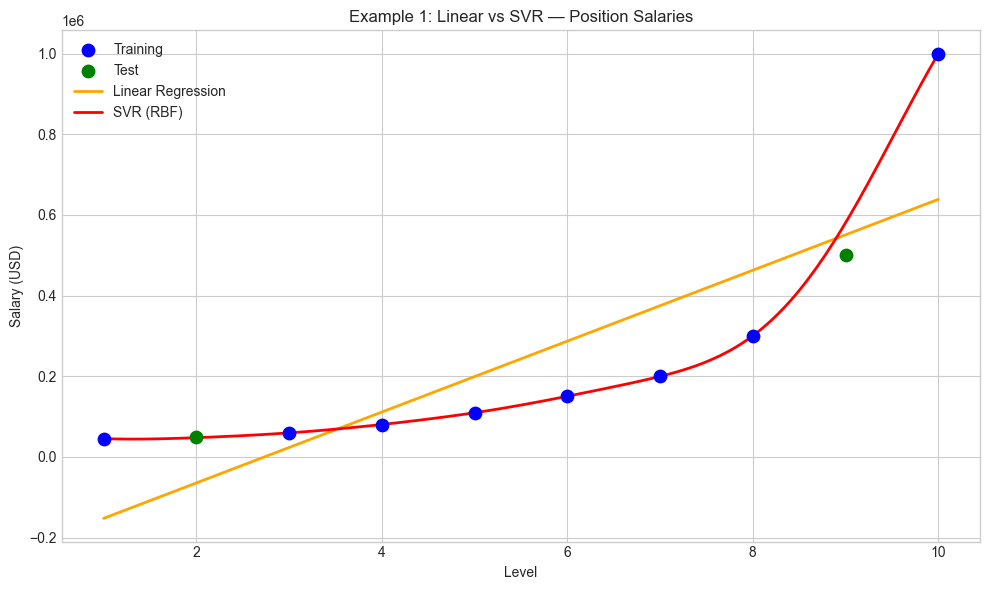

In [70]:
# Step 8) Visualization — Linear vs SVR
from sklearn.linear_model import LinearRegression  # Import for comparison only

X_plot = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)  # 200 points for smooth curve
X_plot_scaled = scaler_X.transform(X_plot)                    # Scale plot points

lin_reg = LinearRegression()           # Simple linear model for comparison
lin_reg.fit(X_train, y_train)          # Train on original (unscaled) data
y_lin = lin_reg.predict(X_plot)        # Linear predictions

y_svr_scaled = regressor.predict(X_plot_scaled)  # SVR predictions (scaled)
y_svr = scaler_y.inverse_transform(y_svr_scaled.reshape(-1, 1)).ravel()  # Back to USD

plt.figure(figsize=(10, 6))  # Create figure
plt.scatter(X_train, y_train, color='blue', label='Training', s=80, zorder=3)   # Training points
plt.scatter(X_test, y_test, color='green', label='Test', s=80, zorder=3)       # Test points
plt.plot(X_plot, y_lin, color='orange', linewidth=2, label='Linear Regression')  # Linear line
plt.plot(X_plot, y_svr, color='red', linewidth=2, label='SVR (RBF)')             # SVR curve
plt.xlabel('Level')            # X-axis label
plt.ylabel('Salary (USD)')    # Y-axis label
plt.title('Example 1: Linear vs SVR — Position Salaries')  # Chart title
plt.legend()                   # Show legend
plt.tight_layout()             # Adjust layout
plt.show()                     # Display plot

## Example 1 — Cell 9: Evaluation

Evaluate SVR with MAE, RMSE, and R² on the test set.

**What this cell does:** Computes and displays evaluation metrics.

In [71]:
# Step 9) Evaluation
mae = mean_absolute_error(y_test, y_pred_test)              # Mean absolute error in USD
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))     # Root mean squared error
r2 = r2_score(y_test, y_pred_test)                          # Variance explained

results = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R²'],
    'Value': [mae, rmse, r2],
    'Description': [
        'Mean Absolute Error (USD)',
        'Root Mean Squared Error (USD)',
        'Coefficient of Determination (1 = perfect)'
    ]
})

display(results.round(4))  # Show metrics table
print(f'\nExample 1 Test R² = {r2:.4f}')  # Print R² summary

,Metric,Value,Description
0,MAE,41440.5270,Mean Absolute Error (USD)
1,RMSE,56962.8132,Root Mean Squared Error (USD)
2,R²,0.9359,Coefficient of Determination (1 = perfect)



Example 1 Test R² = 0.9359


## Why does SVR work well for Position Salaries?

| # | Reason | Explanation |
|---|--------|-------------|
| 1 | **Non-linear relationship** | Salary grows faster at higher levels — not a straight line |
| 2 | **RBF kernel** | SVR can curve to follow the exponential-like salary growth |
| 3 | **Feature scaling applied** | StandardScaler lets SVR optimize correctly |
| 4 | **Better than Linear Regression** | Linear model underfits this curved pattern |
| 5 | **Small dataset** | SVR uses support vectors — works with few data points |

> **Summary:** SVR with RBF kernel fits the **curved** salary-level relationship better than a straight line.

---
# Example 2: Braking Distance — SVR

Predict **Braking Distance** from **Speed**. Physics tells us distance grows **non-linearly** with speed.

| Column | Role | Description |
|--------|------|-------------|
| `Speed_kmh` | Feature (X) | Vehicle speed in km/h |
| `Braking_distance_m` | Target (y) | Braking distance in meters |

**True relationship:** `Distance ≈ 0.04×Speed² + 0.5×Speed + 5` (quadratic)

**File:** `../Datasets/braking_distance.csv`

## Example 2 — Cell 1: Load and Explore Data

Load the braking distance CSV and inspect the data.

**What this cell does:** Reads `../Datasets/braking_distance.csv` and displays basic statistics.

In [72]:
# Step 1) Load dataset
dataset = pd.read_csv('../Datasets/braking_distance.csv')  # Read CSV into a DataFrame

FEATURE_COL = 'Speed_kmh'            # Independent variable (X)
TARGET_COL = 'Braking_distance_m'    # Dependent variable (y)

print('First 5 rows:')
display(dataset.head())

print('\nDataset info:')
dataset.info()

print('\nStatistical summary:')
display(dataset.describe())

print(f'\nShape: {dataset.shape[0]} rows x {dataset.shape[1]} columns')

First 5 rows:


,Speed_kmh,Braking_distance_m
0,20.0,35.0
1,22.0,34.3
2,24.1,45.5
3,26.1,57.5
4,28.2,49.0



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Speed_kmh           49 non-null     float64
 1   Braking_distance_m  49 non-null     float64
dtypes: float64(2)
memory usage: 932.0 bytes

Statistical summary:


,Speed_kmh,Braking_distance_m
count,49.000000,49.000000
mean,70.104082,272.914286
std,30.052544,182.858171
min,20.000000,34.300000
25%,44.500000,108.400000
50%,71.000000,243.000000
75%,95.500000,403.100000
max,120.000000,626.900000



Shape: 50 rows x 2 columns


## Example 2 — Cell 2: Data Cleaning (Handling Missing Values)

This dataset includes missing values to demonstrate `SimpleImputer`.

**What this cell does:** Checks for nulls, removes duplicates, and imputes missing values.

In [73]:
# Step 2) Data cleaning

print('Missing values per column:')
print(dataset.isnull().sum())

rows_before = len(dataset)
dataset = dataset.drop_duplicates().reset_index(drop=True)
rows_after = len(dataset)
print(f'\nDuplicates removed: {rows_before - rows_after}')

imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
if dataset.isnull().sum().sum() > 0:
    dataset[[FEATURE_COL, TARGET_COL]] = imputer.fit_transform(dataset[[FEATURE_COL, TARGET_COL]])
    print('Missing values imputed with mean')
else:
    print('No missing values — imputer not applied')

print(f'\nRows after cleaning: {rows_after}')

Missing values per column:
Speed_kmh             1
Braking_distance_m    1
dtype: int64

Duplicates removed: 0
Missing values imputed with mean

Rows after cleaning: 50


## Example 2 — Cell 3: Categorical Data Encoding

All columns are numeric — encoding is skipped.

**What this cell does:** Confirms no categorical encoding is needed.

In [74]:
# Step 3) Categorical encoding

cat_cols = dataset.select_dtypes(include=['object', 'category']).columns.tolist()
if cat_cols:
    print(f'Categorical columns found: {cat_cols}')
else:
    print('No categorical columns — encoding skipped.')
    print(f'Feature: {FEATURE_COL}, Target: {TARGET_COL}')

No categorical columns — encoding skipped.
Feature: Speed_kmh, Target: Braking_distance_m


## Example 2 — Cell 4: Splitting the Data

Define X (Speed) and y (Distance), then split 80/20.

**What this cell does:** Creates feature/target arrays and applies train_test_split.

In [75]:
# Step 4) Train-Test split

X = dataset[[FEATURE_COL]].values
y = dataset[TARGET_COL].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape:  {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape:  {y_test.shape}')

X_train shape: (40, 1)
X_test shape:  (10, 1)
y_train shape: (40,)
y_test shape:  (10,)


## Example 2 — Cell 5: Feature Scaling (Required for SVR)

Standardize features and target before SVR training.

**What this cell does:** Applies StandardScaler to train and test sets.

In [76]:
# Step 5) Feature scaling

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

print('Feature scaling applied (StandardScaler).')

Feature scaling applied (StandardScaler).


## Example 2 — Cell 6: Train the Model

Train SVR with RBF kernel on scaled data.

**What this cell does:** Fits SVR and prints support vector count.

In [77]:
# Step 6) Train SVR model

SVR_KERNEL = 'rbf'
SVR_C = 100               # Works well on braking distance
SVR_EPSILON = 0.1
SVR_GAMMA = 'scale'

regressor = SVR(
    kernel=SVR_KERNEL,
    C=SVR_C,
    epsilon=SVR_EPSILON,
    gamma=SVR_GAMMA
)

regressor.fit(X_train_scaled, y_train_scaled)

print('SVR model trained successfully.')
print(f'Support vectors used: {regressor.n_support_}')
print(f'Hyperparameters: kernel={SVR_KERNEL}, C={SVR_C}, epsilon={SVR_EPSILON}, gamma={SVR_GAMMA}')

SVR model trained successfully.
Support vectors used: [9]
Hyperparameters: kernel=rbf, C=100, epsilon=0.1, gamma=scale


## Example 2 — Cell 7: Predict

Predict braking distance and inverse-transform to meters.

**What this cell does:** Generates predictions on the test set.

In [78]:
# Step 7) Predict

y_pred_scaled = regressor.predict(X_test_scaled)
y_pred_test = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

print('Sample predictions (Test set):')
for i in range(min(5, len(y_test))):
    print(f'  Speed={X_test[i][0]:.1f} km/h -> Actual={y_test[i]:.1f}m, Predicted={y_pred_test[i]:.1f}m')

Sample predictions (Test set):
  Speed=46.5 km/h -> Actual=99.4m, Predicted=121.4m
  Speed=99.6 km/h -> Actual=453.2m, Predicted=452.1m
  Speed=81.2 km/h -> Actual=304.5m, Predicted=303.7m
  Speed=111.8 km/h -> Actual=555.1m, Predicted=555.7m
  Speed=54.7 km/h -> Actual=154.5m, Predicted=150.5m


## Example 2 — Cell 8: Visualization

Plot data with Linear vs SVR curves.

**What this cell does:** Visualizes how SVR captures the quadratic pattern.

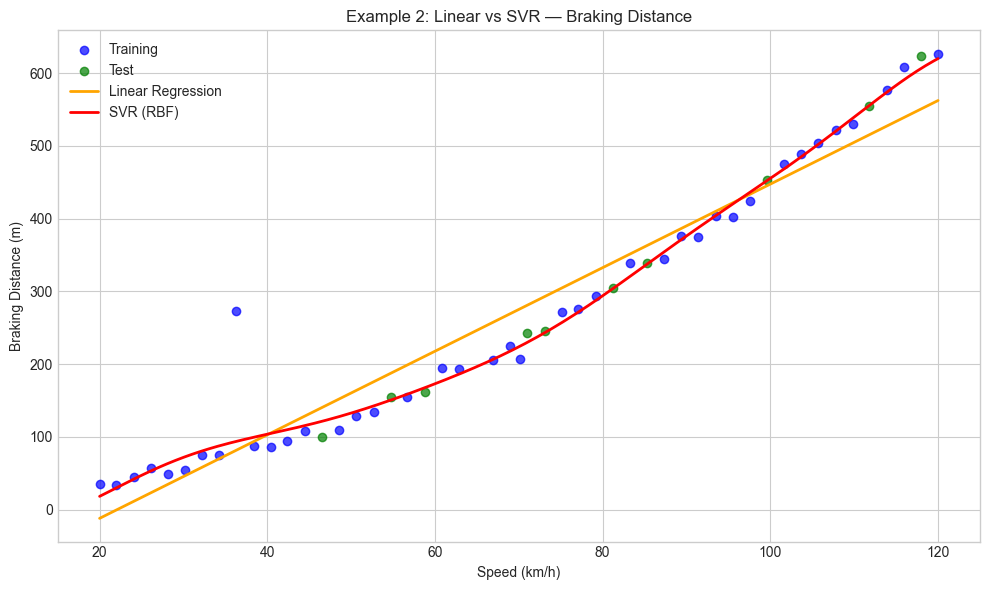

In [79]:
# Step 8) Visualization
from sklearn.linear_model import LinearRegression

X_plot = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
X_plot_scaled = scaler_X.transform(X_plot)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_lin = lin_reg.predict(X_plot)

y_svr_scaled = regressor.predict(X_plot_scaled)
y_svr = scaler_y.inverse_transform(y_svr_scaled.reshape(-1, 1)).ravel()

plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', label='Training', alpha=0.7)
plt.scatter(X_test, y_test, color='green', label='Test', alpha=0.7)
plt.plot(X_plot, y_lin, color='orange', linewidth=2, label='Linear Regression')
plt.plot(X_plot, y_svr, color='red', linewidth=2, label='SVR (RBF)')
plt.xlabel('Speed (km/h)')
plt.ylabel('Braking Distance (m)')
plt.title('Example 2: Linear vs SVR — Braking Distance')
plt.legend()
plt.tight_layout()
plt.show()

## Example 2 — Cell 9: Evaluation

Evaluate SVR performance with MAE, RMSE, and R².

**What this cell does:** Computes and displays evaluation metrics.

In [80]:
# Step 9) Evaluation
mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2 = r2_score(y_test, y_pred_test)

results = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R²'],
    'Value': [mae, rmse, r2],
    'Description': [
        'Mean Absolute Error (meters)',
        'Root Mean Squared Error (meters)',
        'Coefficient of Determination (1 = perfect)'
    ]
})

display(results.round(4))
print(f'\nExample 2 Test R² = {r2:.4f}')

,Metric,Value,Description
0,MAE,6.8673,Mean Absolute Error (meters)
1,RMSE,10.0511,Root Mean Squared Error (meters)
2,R²,0.9964,Coefficient of Determination (1 = perfect)



Example 2 Test R² = 0.9964


## Why does SVR work well for Braking Distance?

| # | Reason | Explanation |
|---|--------|-------------|
| 1 | **Quadratic physics** | Braking distance ∝ speed² — inherently curved |
| 2 | **RBF kernel fits curves** | SVR follows the upward curve better than a line |
| 3 | **Scaling applied** | Speed and distance on different scales — StandardScaler fixes this |
| 4 | **More data (50 rows)** | More points help SVR define the curve accurately |
| 5 | **Higher R² than Linear** | Linear regression cannot capture speed² growth |

> **Compare:** Linear Regression gives moderate R²; **SVR (RBF)** typically achieves **R² > 0.95** on this dataset.